## **TLC 승차 건 카운팅**

In [3]:
from pyspark import SparkConf, SparkContext
import pandas as pd

**SparkConf**
사용자가 재정의해서 쓸 수 있는 설정 옵션들에 대한 키와 값을 갖고있는 객체


**SparkContext**
Spark 클러스터와 연결시켜주는 객체


* Spark 모든 기능에 접근할 수 있는 시작점
* Spark는 분산환경에서 동작하기 때문에 Driver Program 을 구동시키기 위해 SparkContext가 필요
* SparkContext는 프로그램당 하나만 만들 수 있고 사용후에는 종료


#### **SparkContext 초기화**

![sparkcontext](assets/sparkcontext.png)

* SparkContext 객체는 내부에 자바로 동작하는 Py4J의 SparkContext와 연결
* 이 덕분에 파이썬으로 코딩하면서도 자바 위에서 동작하는 프로그램을 작성할 수 있다 
* RDD를 만들 수 있다

In [4]:
# Configure Spark 
conf = SparkConf().setMaster("local").setAppName("uber-date-trips")
sc = SparkContext(conf=conf).getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/29 04:30:01 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


setMaster("local") - 분산된 환경이 아닌 개발용 로컬 환경을 쓴다

setAppName - Spark UI에서 확인 가능한 스파크 앱 이름

In [5]:
# Dataset sample
path = "../data/"  # data 디렉토리 경로
filename = "fhvhv_tripdata_2020-03_short.csv"

#### **데이터 로딩후 RDD 생성**

In [6]:
lines = sc.textFile(path + filename)   # .csv -> RDD object #실질적으로 파일을 읽는 역할 text기반의 폼에서 읽을 때 사용 그 외 스파크에서 io 지원하는 것이 다양함

In [7]:
header = lines.first() # RDD 객체의 첫번째 값을 얻어오는 객체

In [8]:
header

'hvfhs_license_num,dispatching_base_num,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,SR_Flag'

*데이터*
```
hvfhs_license_num,dispatching_base_num,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,SR_Flag
HV0005,B02510,2020-03-01 00:03:40,2020-03-01 00:23:39,81,159,
HV0005,B02510,2020-03-01 00:28:05,2020-03-01 00:38:57,168,119,
HV0003,B02764,2020-03-01 00:03:07,2020-03-01 00:15:04,137,209,1
HV0003,B02764,2020-03-01 00:18:42,2020-03-01 00:38:42,209,80,
HV0003,B02764,2020-03-01 00:44:24,2020-03-01 00:58:44,256,226,
...
```

#### **필요한 부분만 추출하기**

In [9]:
filtered_lines = lines.filter(lambda row:row != header) # all lines excepting the header #필터 메서드는 내가 선택하고자 하는 데이터의 조건을 명시하는 형태
#람다 뒤에 로우는 filter 는 lines 에 대응해서 실행이 되는 데 line은 rdd 객체를 부릴수 있는데 row는 lines이라는 rdd 객체의 개별 rdd 값을 나타냄
#첫번째줄도 rdd , 2번쨰줄도 rdd 하나의 줄을 rdd값으로 저장
#row는 계속 바뀌는 변수 이것이 header와 같지 않다는 조건문 filter 메서드가 이 조건문에 해당하는 row만 고른다는 의미

아래와 같습니다
```python
def f(row):
    return row != header
lines.filter(f) 
```

*데이터*
```
HV0005,B02510,2020-03-01 00:03:40,2020-03-01 00:23:39,81,159, 
HV0005,B02510,2020-03-01 00:28:05,2020-03-01 00:38:57,168,119,
HV0003,B02764,2020-03-01 00:03:07,2020-03-01 00:15:04,137,209,1
HV0003,B02764,2020-03-01 00:18:42,2020-03-01 00:38:42,209,80,
HV0003,B02764,2020-03-01 00:44:24,2020-03-01 00:58:44,256,226,
...
```

In [10]:
dates = filtered_lines.map(lambda x: x.split(",")[2].split(" ")[0]) 
#일자 정보가 필요, 지금까지 처리한 데이터는 filtered_lines에 있음
#map메서드는 rdd v1 을 rdd v2 로 변환을 하는데 value by value로 1대1 형태로 매핑
#각 라인이 현재의 rdd value, 어떤 부분을 바꿀지를 뒤에 lamda 코드로 지정
#x는 개별적인 모든 rdd 값을 말함, x.split(",")[2] , 를 만났을때 문자를 자름 , 총 6개로 쪼개짐(만약 지정을 안하면 디폴트가 공백) 나눈것 중 2번 데이터 로 설정 (pickup date)
#그 뒤 공백 문자를 기준으로 쪼개고 0번 엘리먼트를 취하면 일별 데이터를 얻을 수 있

```map()```함수로 우리가 원하는 부분만 추출 할 수 있다


추출하는 함수
```python
lambda x: x.split(",")[2].split(" ")[0]

```
아래와 같다

```python]
def f(x):
    return x.split(",")[2].split(" ")[0]
```


오리지널 데이터
```
HV0005,B02510,2020-03-01 00:03:40,2020-03-01 00:23:39,81,159,
```

x.split(",")
```
[HV0005,B02510,2020-03-01 00:03:40,2020-03-01 00:23:39,81,159,]
```


x.split(",")[2]
```
[2020-03-01 00:03:40]
```


x.split(",")[2].split(" ")
```
[2020-03-01,00:03:40]
```

x.split(",")[2].split(" ")[0]
```
2020-03-01
```

#### **CountByValue( )**

In [11]:
result = dates.countByValue() # Transformation, Action #countbyvlaue는 value가 몇번 등장했는지 세줌, action 메소드

값이 얼마나 등장하는지 세준다 

예)
```
2020-03-01
2020-03-01
2020-03-01
2020-03-02
2020-03-02
2020-03-03
```
countByValue()
```
(2020-03-01,3)
(2020-03-02,2)
(2020-03-03,1)
```


**result는 이제 더이상 RDD가 아닌 Python 객체**

In [12]:
result #action은 결과를 확인해야하는 시점에서 사용되는 메서드 rdd 객체일때는 중간결과를 확인하기 어려움, rdd 객체를 파이썬 객체로 변환해서 결과를 보여줌

defaultdict(int,
            {'2020-03-01': 784246,
             '2020-03-02': 648986,
             '2020-03-03': 697880,
             '2020-03-04': 707879,
             '2020-03-05': 731165,
             '2020-03-06': 872012,
             '2020-03-07': 418828})

In [20]:
# Save results as a csv file 
pd.Series(result, name="trips").to_csv("trips_date.csv")

<Axes: >

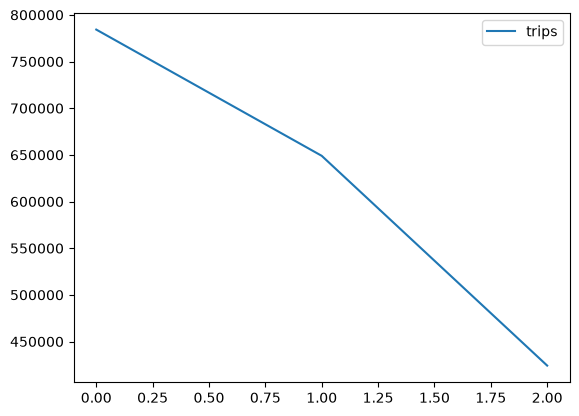

----------------------------------------
Exception occurred during processing of request from ('127.0.0.1', 42488)
Traceback (most recent call last):
  File "/opt/bitnami/python/lib/python3.12/socketserver.py", line 318, in _handle_request_noblock
    self.process_request(request, client_address)
  File "/opt/bitnami/python/lib/python3.12/socketserver.py", line 349, in process_request
    self.finish_request(request, client_address)
  File "/opt/bitnami/python/lib/python3.12/socketserver.py", line 362, in finish_request
    self.RequestHandlerClass(request, client_address, self)
  File "/opt/bitnami/python/lib/python3.12/socketserver.py", line 766, in __init__
    self.handle()
  File "/opt/bitnami/spark/python/pyspark/accumulators.py", line 295, in handle
    poll(accum_updates)
  File "/opt/bitnami/spark/python/pyspark/accumulators.py", line 267, in poll
    if self.rfile in r and func():
                           ^^^^^^
  File "/opt/bitnami/spark/python/pyspark/accumulators.py", li

In [21]:
# Visualize the results
import matplotlib.pyplot as plt
%matplotlib inline  

trips = pd.read_csv("trips_date.csv")
trips.plot()